# Title: Unveiling the Cosmos: Classifying Stars, Galaxies and Quasars.
A Machine Learning Journey through Astronomical Objects.

Team Members:

*  Hariharan Chitra Muthukumar - 87523108
*  Parampreet Kaur Sukhvinder Singh  Bhela- 81130840




The Cosmic Challenge(Problem Statement).

So what are we actually trying to solve?
Have you ever imagine looking up in the sky at night and wondering like, its full of uncountable lights! But our question is like what actually are they?
Are they twinking "Stars" like our sun?
Are they a huge collection of Stars, dust and gases called "Galaxies"?
or
Are they bright, distant objects powered by super massive black holes, known as "Quasars"?

Our big challenge in this project is to build a computer program which is obviously called as Machine Learning models that can automatically identify the different celestial bodies based on their lights and other properties. This can help astronomers to understand our universe better and faster!

To teach our programs we actually need examples which is called as Data in programing language.
So here we are using the Data called as ***star_classification.csv***
Its a huge collection of photos and measurements taken by powerful telescope like the Sloan Digital Sky Survey.


Each row in our dataset is like a detailed description of one object in the sky.

It tells us things like:
* **How bright it is** in different colors of light (like u, g, r, i, z - imagine them as different colored glasses the telescope is  wearing!).
* **Where it is** in the sky (alpha, delta).
* And most importantly, what **class** it actually is: a GALAXY, a STAR, or a QSO.


---



Our role is to enable the computer to use existing descriptions to accurately identify celestial objects it encounters for the first time.


So here we start working by loading our dataset.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/drive/MyDrive/dataset/star_classification.csv")
df.head()

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842


Basic information about our dataset like checking its size and columns ad a quick lookout for the different type of sky objects in our dataset.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   obj_ID       100000 non-null  float64
 1   alpha        100000 non-null  float64
 2   delta        100000 non-null  float64
 3   u            100000 non-null  float64
 4   g            100000 non-null  float64
 5   r            100000 non-null  float64
 6   i            100000 non-null  float64
 7   z            100000 non-null  float64
 8   run_ID       100000 non-null  int64  
 9   rerun_ID     100000 non-null  int64  
 10  cam_col      100000 non-null  int64  
 11  field_ID     100000 non-null  int64  
 12  spec_obj_ID  100000 non-null  float64
 13  class        100000 non-null  object 
 14  redshift     100000 non-null  float64
 15  plate        100000 non-null  int64  
 16  MJD          100000 non-null  int64  
 17  fiber_ID     100000 non-null  int64  
dtypes: float64(10), int64(7),

Cleaning and prepairing:
Checking for the missing values or outliers.

In [ ]:
df.isnull().sum(0)

,0
obj_ID,0
alpha,0
delta,0
u,0
g,0
r,0
i,0
z,0
run_ID,0
rerun_ID,0


Looking at our data through statistical approach.

In [ ]:
df.describe()

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,redshift,plate,MJD,fiber_ID
count,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.0,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000
mean,1.237665e+18,177.629117,24.135305,21.980468,20.531387,19.645762,19.084854,18.668810,4481.366060,301.0,3.511610,186.130520,5.783882e+18,0.576661,5137.009660,55588.647500,449.312740
std,8.438560e+12,96.502241,19.644665,31.769291,31.750292,1.854760,1.757895,31.728152,1964.764593,0.0,1.586912,149.011073,3.324016e+18,0.730707,2952.303351,1808.484233,272.498404
min,1.237646e+18,0.005528,-18.785328,-9999.000000,-9999.000000,9.822070,9.469903,-9999.000000,109.000000,301.0,1.000000,11.000000,2.995191e+17,-0.009971,266.000000,51608.000000,1.000000
25%,1.237659e+18,127.518222,5.146771,20.352353,18.965230,18.135828,17.732285,17.460677,3187.000000,301.0,2.000000,82.000000,2.844138e+18,0.054517,2526.000000,54234.000000,221.000000
50%,1.237663e+18,180.900700,23.645922,22.179135,21.099835,20.125290,19.405145,19.004595,4188.000000,301.0,4.000000,146.000000,5.614883e+18,0.424173,4987.000000,55868.500000,433.000000
75%,1.237668e+18,233.895005,39.901550,23.687440,22.123767,21.044785,20.396495,19.921120,5326.000000,301.0,5.000000,241.000000,8.332144e+18,0.704154,7400.250000,56777.000000,645.000000
max,1.237681e+18,359.999810,83.000519,32.781390,31.602240,29.571860,32.141470,29.383740,8162.000000,301.0,6.000000,989.000000,1.412694e+19,7.011245,12547.000000,58932.000000,1000.000000


In [ ]:
print(df['class'].value_counts())


class
GALAXY    59445
STAR      21594
QSO       18961
Name: count, dtype: int64


Distribution of the objects with the help of bar chart.




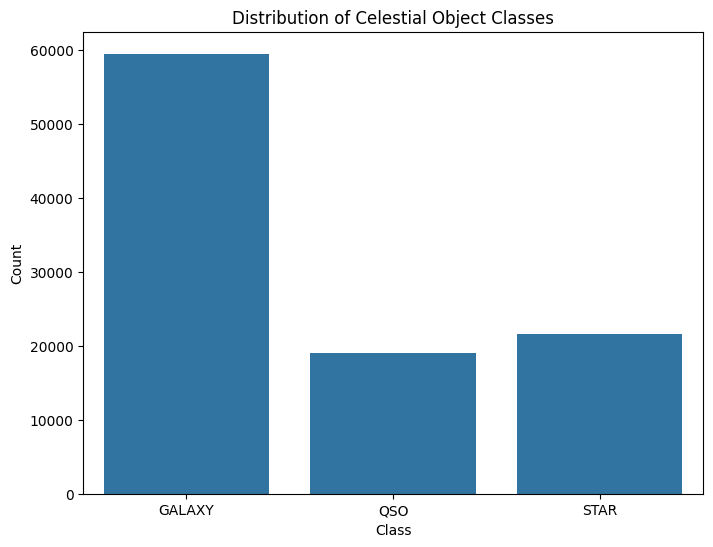

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(x='class', data=df)
plt.title('Distribution of Celestial Object Classes')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

Splitting the data for training(80%) and test(20%) sets.

In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split ,GridSearchCV ,RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


for col in ['u', 'g', 'z']:
    df[col] = df[col].replace(-9999.0, np.nan)
    df[col] = df[col].fillna(df[col].median())

le = LabelEncoder()
df['class_encoded'] = le.fit_transform(df['class'])
class_names = le.classes_
columns_to_drop = [
    'obj_ID', 'rerun_ID', 'class',
    'run_ID', 'cam_col', 'field_ID', 'spec_obj_ID', 'plate', 'MJD', 'fiber_ID'
]
df_cleaned = df.drop(columns=columns_to_drop, errors='ignore')

X = df_cleaned.drop('class_encoded', axis=1)
y = df_cleaned['class_encoded']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

Baseline model: Logistic Regression

In [ ]:
baseline_model = LogisticRegression(solver='liblinear', random_state=42, max_iter=200)
baseline_model.fit(X_train, y_train)

y_pred = baseline_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))


Accuracy: 0.9392

Classification Report:
              precision    recall  f1-score   support

      GALAXY       0.95      0.95      0.95     11889
         QSO       0.93      0.91      0.92      3792
        STAR       0.93      0.93      0.93      4319

    accuracy                           0.94     20000
   macro avg       0.93      0.93      0.93     20000
weighted avg       0.94      0.94      0.94     20000



Confusion matrix: To give a visual representation that for how many times logistic regression model have accurately predicted the class of the objects.


Confusion Matrix:


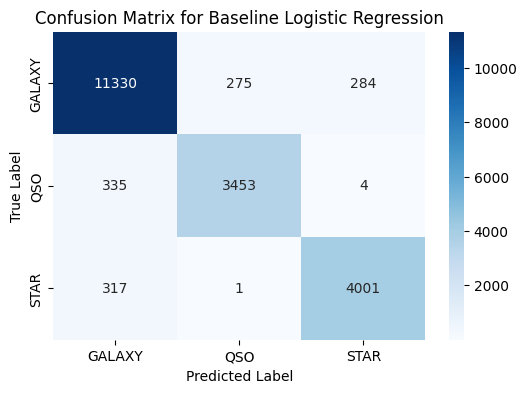

In [ ]:
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")

plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Baseline Logistic Regression')
plt.show()

Here we are working with three more different models:

*  Random Forest Classifier.
*  Gradient Boosting Classifier.
*  SVC Classifier

For each we are working with twoo methods:

*   Grid Search.
*   Randomized Search.







In [ ]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

print("\n--- Automated Model Adaptation (Analogy to LLM Fine-tuning) ---")

models_to_adapt = {
    "RandomForest_Classifier": {
        "estimator": RandomForestClassifier(random_state=42),
        "adaptation_settings_grid": {
            'n_estimators': [100],
            'max_depth': [20],
        },
        "adaptation_method": "GridSearch"
    },
    "GradientBoosting_Classifier": {
        "estimator": GradientBoostingClassifier(random_state=42),
        "adaptation_settings_grid": {
            'n_estimators': [100],
            'learning_rate': [0.1],
        },
        "adaptation_method": "GridSearch"
    },
    "SVC_Classifier": {
        "estimator": SVC(random_state=42),
        "adaptation_settings_grid": {
            'C': [1],
            'gamma': ['scale'],
        },
        "adaptation_method": "RandomizedSearch"
    }
}

adapted_results = {}
unadapted_results_summary = {}

for model_name, config in models_to_adapt.items():
    print(f"\n--- Adapting {model_name} ---")

    general_model_estimator = config["estimator"]
    adaptation_settings_grid = config["adaptation_settings_grid"]
    adaptation_method = config["adaptation_method"]

    # Evaluate UN-ADAPTED model
    unadapted_model = general_model_estimator
    unadapted_model.fit(X_train, y_train)
    y_pred_unadapted = unadapted_model.predict(X_test)
    unadapted_results_summary[model_name] = accuracy_score(y_test, y_pred_unadapted)
    print(f"Accuracy (Un-adapted): {unadapted_results_summary[model_name]:.4f}")

    # Perform Automated Adaptation
    if adaptation_method == "GridSearch":
        adaptation_search = GridSearchCV(estimator=general_model_estimator,param_grid=adaptation_settings_grid,cv=2, scoring='accuracy', n_jobs=-1, verbose=0)
    else:
        adaptation_search = RandomizedSearchCV(estimator=general_model_estimator, param_distributions=adaptation_settings_grid,n_iter=1, cv=2, scoring='accuracy', n_jobs=-1, verbose=0, random_state=42)

    adaptation_search.fit(X_train, y_train)
    best_adaptation_params = adaptation_search.best_params_
    print(f"Best settings found: {best_adaptation_params}")

    # Train and evaluate ADAPTED model
    final_adapted_model = general_model_estimator.__class__(**best_adaptation_params, random_state=42)
    final_adapted_model.fit(X_train, y_train)
    y_pred_adapted = final_adapted_model.predict(X_test)
    accuracy_adapted = accuracy_score(y_test, y_pred_adapted)

    adapted_results[model_name] = {
        "accuracy_test": accuracy_adapted,
        "best_params": best_adaptation_params
    }

    print(f"Accuracy (Adapted): {accuracy_adapted:.4f}")
    print("Classification Report (Adapted):")
    print(classification_report(y_test, y_pred_adapted, target_names=class_names))
    print("Confusion Matrix (Adapted):")
    print(confusion_matrix(y_test, y_pred_adapted))




--- Automated Model Adaptation (Analogy to LLM Fine-tuning) ---

--- Adapting RandomForest_Classifier ---
Accuracy (Un-adapted): 0.9798
Best settings found: {'max_depth': 20, 'n_estimators': 100}
Accuracy (Adapted): 0.9798
Classification Report (Adapted):
              precision    recall  f1-score   support

      GALAXY       0.98      0.99      0.98     11889
         QSO       0.97      0.93      0.95      3792
        STAR       0.99      1.00      1.00      4319

    accuracy                           0.98     20000
   macro avg       0.98      0.97      0.98     20000
weighted avg       0.98      0.98      0.98     20000

Confusion Matrix (Adapted):
[[11749   116    24]
 [  262  3530     0]
 [    1     0  4318]]

--- Adapting GradientBoosting_Classifier ---
Accuracy (Un-adapted): 0.9769
Best settings found: {'learning_rate': 0.1, 'n_estimators': 100}
Accuracy (Adapted): 0.9769
Classification Report (Adapted):
              precision    recall  f1-score   support

      GALAXY  

Evaluation Criterion:

1] Accuracy Score

2] Classification report

3] Confusion Matrix